**DataXperience — Universidad EAN**

# Predicción de la Presencia de Artistas en Playlists Editoriales de Spotify

Notebook completo del proyecto: carga, diagnóstico, limpieza, normalización, análisis exploratorio (EDA) y modelo de regresión. Corre de principio a fin sin depender de Google Drive.

**Para ejecutarlo:** al llegar a la primera celda de código va a pedir subir `dirty_spotify_artists_facil.csv` y `dirty_spotify_tracks_facil.csv` (están en la carpeta `data/` de este repositorio).

## 1. Cargue y diagnóstico inicial

### Diagnóstico inicial — artists y tracks

Ambas tablas cargaron sin problemas y coinciden con lo documentado:

| Tabla | Filas | Columnas |
|---|---|---|
| **artists** | 21,270 | 13 |
| **tracks** | 15,811 | 23 |

####  Artists — puntaje 99.3/100, pero engañoso

`auditoria_calidad()` solo detecta nulos reales (NaN); aquí el problema son **placeholders disfrazados de texto válido**:

- **Tipos rotos:** `monthly_listeners` ("23.7M"), `popularity` y `num_tracks` ("N/A"/"unknown"), y `followers` (separador de miles) quedaron como texto en vez de número.
- **1,013 duplicados exactos** (~4.8%) — cuadra con el ~5% esperado.
- **Cronología sospechosa:** `first_release`, `last_release` y `num_releases` disparan atípicos IQR (1,642 / 1,196 / 840) → posible año invertido o valor centinela 9999.
- **Falso positivo:** la función marca `monthly_listeners` y `followers` como "posible identificador", pero son solo numéricas continuas de alta cardinalidad.

####  Tracks — puntaje 99.1/100, misma trampa

- **Columna sobrante:** `Unnamed: 0`, artefacto de exportación.
- **"0 duplicados" es un espejismo:** `Unnamed: 0` actúa como índice único y le impide a `duplicated()` ver contenido repetido. La pista real: `ids` tiene **753 valores menos** que el total de filas, aunque el grain debería ser un track = una fila.
- **Faltantes parejos:** las 9 audio features (`acousticness` → `valence`) faltan casi por igual (1.4%–1.6%) → coincide con el fallo simulado del fetch al API.
- **Atípicos a investigar:** `liveness`, `loudness`, `speechiness` y `time_signature` acumulan más atípicos que el resto, posiblemente por distribuciones muy concentradas y valores fuera de dominio (como `loudness` positivo).

In [1]:
# ETAPA: 1. Cargue y Diagnóstico de Calidad
# 01. Cargar artists_facil y tracks_facil con cargar_datos()

# Importar librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Crear funcion para cargar los datos (Notebook: Caja_de_Herramientas_Cargue_Limpieza_EDA)
def cargar_datos(ruta, **kwargs):
    """
    Carga un archivo .csv, .xlsx o .json y devuelve un DataFrame.
    kwargs se pasan directo a la función de pandas que corresponda
    (por ejemplo: cargar_datos("ventas.csv", sep=";", decimal=",")).
    Si algo falla, avisa con un mensaje claro y devuelve None.
    """
    extension = ruta.split(".")[-1].lower()

    try:
        if extension == "csv":
            df = pd.read_csv(ruta, **kwargs)
        elif extension in ("xlsx", "xls"):
            df = pd.read_excel(ruta, **kwargs)
        elif extension == "json":
            df = pd.read_json(ruta, **kwargs)
        else:
            print(f"❌ Extensión '.{extension}' no reconocida. Usa .csv, .xlsx o .json.")
            return None
    except FileNotFoundError:
        print(f"❌ No encuentro el archivo '{ruta}'. Revisa el nombre y que ya lo hayas subido a Colab.")
        return None
    except Exception as error:
        print(f"❌ El archivo existe pero no se pudo leer. Detalle: {error}")
        return None

    print(f"✅ Cargado '{ruta}': {df.shape[0]} filas, {df.shape[1]} columnas.")
    return df

# Ejemplo: RetoG05 (subir archivo si no está en la sesión)
import os

archivos = {
    "artist": "dirty_spotify_artists_facil.csv",
    "track": "dirty_spotify_tracks_facil.csv",
}
for nombre, ARCHIVO in archivos.items():
    if not os.path.exists(ARCHIVO):
        try:
            from google.colab import files
            print(f"Suban el archivo '{ARCHIVO}'")
            subidos = files.upload()
            archivos[nombre] = list(subidos.keys())[0]
        except ImportError:
            raise FileNotFoundError(f"No encuentro '{ARCHIVO}'. Póngalo junto a este cuaderno.")

artist = cargar_datos(archivos["artist"])
track = cargar_datos(archivos["track"])


# 02. Revisar shape y dtypes de ambas tablas
print(artist.dtypes)
print(track.dtypes)

✅ Cargado 'dirty_spotify_artists_facil.csv': 21270 filas, 13 columnas.
✅ Cargado 'dirty_spotify_tracks_facil.csv': 15811 filas, 23 columnas.
dates                    str
ids                      str
names                    str
monthly_listeners        str
popularity               str
followers                str
genres                   str
first_release        float64
last_release         float64
num_releases         float64
num_tracks               str
playlists_found          str
feat_track_ids           str
dtype: object
Unnamed: 0            int64
ids                     str
names                   str
popularity          float64
markets                 str
artists                 str
release_date            str
duration_ms         float64
acousticness        float64
danceability        float64
energy              float64
instrumentalness    float64
liveness            float64
loudness            float64
speechiness         float64
tempo               float64
valence             

In [2]:
# 03. Correr auditoria_calidad() sobre artists y tracks


#Crear funciones para verificar datos (Notebook: Caja_de_Herramientas_Cargue_Limpieza_EDA)
def detectar_atipicos_iqr(serie):
    """
    Devuelve una Serie de True/False: True donde el valor es atípico,
    según la regla de 1.5 veces el rango intercuartílico (Q3 - Q1).
    Es la misma regla que usa un boxplot para decidir qué puntos dibujar sueltos.
    """
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    return (serie < limite_inferior) | (serie > limite_superior)


def auditoria_calidad(df):
    """
    Genera un reporte de calidad, una fila por columna: tipo de dato,
    % de valores faltantes, cantidad de valores únicos, un semáforo de
    diagnóstico y (solo en columnas numéricas) cuántos atípicos tiene.
    Imprime un puntaje general y DEVUELVE el reporte como DataFrame.
    """
    filas_reporte = []
    for columna in df.columns:
        pct_nulos = df[columna].isna().mean() * 100
        n_unicos = df[columna].nunique()

        if pct_nulos > 40:
            estado = "🔴 Inutilizable"
        elif pct_nulos > 10:
            estado = "🟡 Requiere tratamiento"
        else:
            estado = "🟢 Aceptable"

        if df[columna].dtype == "object" and n_unicos > len(df) * 0.5:
            estado += " · posible identificador"

        if pd.api.types.is_numeric_dtype(df[columna]):
            n_atipicos = detectar_atipicos_iqr(df[columna].dropna()).sum()
        else:
            n_atipicos = "—"

        filas_reporte.append({
            "columna": columna, "tipo": str(df[columna].dtype),
            "% faltantes": round(pct_nulos, 1), "valores_unicos": n_unicos,
            "atipicos_iqr": n_atipicos, "diagnostico": estado,
        })

    reporte = pd.DataFrame(filas_reporte)
    puntaje = round(100 - reporte["% faltantes"].mean(), 1)

    print(f"Puntaje general de calidad: {puntaje}/100")
    print(f"Filas totales: {len(df)}  ·  Filas duplicadas: {df.duplicated().sum()}")

    return reporte


#auditoria_calidad(artist)
auditoria_calidad(track)

Puntaje general de calidad: 99.1/100
Filas totales: 15811  ·  Filas duplicadas: 0


## 2. Limpieza — Artists

#### Limpieza — Artists

Se aplicaron los 6 pasos de limpieza en orden, con las siguientes decisiones:

1. **Nombres de columnas:** ya venían limpios y consistentes (snake_case), no requirió cambios.
2. **Duplicados exactos:** se detectaron y eliminaron 6 filas `CORRUPT_ROW` (casi vacías, basura) y luego los duplicados exactos restantes con `drop_duplicates()` → de 21,270 a 20,251 filas.
3. **Texto (espacios/mayúsculas):** `.strip()` en todas las columnas de texto, `.lower()` solo en `names` — `ids` y `genres` no se tocan en mayúsculas porque son identificadores o necesitan mantener su formato original.
4. **Categorías equivalentes:** placeholders `"?"`, `"unknown"`, `"--"` convertidos a `NaN` real; `followers` (separador de miles) y `monthly_listeners` (abreviaturas "K"/"M") convertidos a numérico; delimitador de `genres` unificado (`;` y `|` → `,`).
5. **Valores imposibles:** `popularity` fuera de [0, 100] y `followers` negativos → `NaN`. Cronología de releases: 61 filas con año centinela `9999` y 60 con `first_release > last_release` (inversión imposible) → `NaN` en ambas columnas, porque no hay forma confiable de saber cuál de las dos está mal.
6. **Valores faltantes:** columnas numéricas (`monthly_listeners`, `popularity`, `followers`, `num_tracks`) imputadas con la mediana; columnas de texto (`genres`, `playlists_found`) con un valor fijo ("Sin género" / "Sin dato"); filas con cronología imposible descartadas (no imputadas) con `dropna(subset=["first_release","last_release"])`.

**Impacto:** 1,140 filas eliminadas en total (5.4% del dataset original: 6 CORRUPT_ROW + duplicados + cronología imposible). Puntaje de calidad final: **100.0/100**, subió desde el 99.3/100 engañoso del diagnóstico inicial (que no detectaba los placeholders de texto, solo `NaN` real).

In [3]:
# ETAPA: 2. Limpieza — Artists
# 01. Detectar y eliminar filas CORRUPT_ROW_0...5
print("Filas CORRUPT_ROW:", len(artist[artist["ids"].str.contains("CORRUPT_ROW")]))

artist_limpio = artist.copy()
artist_limpio = artist_limpio[~artist_limpio["ids"].str.contains("CORRUPT_ROW")]

# 02. Eliminar duplicados exactos
artist_limpio = artist_limpio.drop_duplicates().reset_index(drop=True)
print("Filas sin CORRUPT_ROW ni duplicados:", len(artist_limpio))

Filas CORRUPT_ROW: 6
Filas sin CORRUPT_ROW ni duplicados: 20251


In [4]:
# 03. Limpiar texto: strip y mayúsculas en names, ids, genres
columnas_texto = artist_limpio.select_dtypes(include="object").columns
for columna in columnas_texto:
    artist_limpio[columna] = artist_limpio[columna].str.strip()

artist_limpio["names"] = artist_limpio["names"].str.lower()

artist_limpio[["names", "ids"]].head()

In [5]:
# 04. Convertir placeholders (?, unknown, --) a NaN real
# Ejemplo: Caja de Herramientas (categorías equivalentes a NaN real)
placeholders = ["?", "unknown", "--"]
for columna in artist_limpio.columns:
    artist_limpio.loc[artist_limpio[columna].isin(placeholders), columna] = np.nan
print(artist_limpio[["popularity", "num_tracks"]].isna().sum())

# 05. Convertir dates a datetime
fechas = artist_limpio["dates"].str.replace(" 00:00:00", "", regex=False)
es_iso = fechas.str.contains("-")
artist_limpio["dates"] = pd.concat([pd.to_datetime(fechas[es_iso]), pd.to_datetime(fechas[~es_iso])])
print(artist_limpio["dates"].min(), artist_limpio["dates"].max())

popularity    121
num_tracks    122
dtype: int64
2024-04-01 00:00:00 2024-05-09 00:00:00


In [6]:
# 06. Arreglar followers (quitar comas) y monthly_listeners (parsear K/M) a numérico
artist_limpio["followers"] = artist_limpio["followers"].str.replace(",", "", regex=False)
artist_limpio["followers"] = pd.to_numeric(artist_limpio["followers"], errors="coerce")

monthly = artist_limpio["monthly_listeners"].fillna("")
es_miles = monthly.str.contains("K")
es_millones = monthly.str.contains("M")
monthly = monthly.str.replace("K", "", regex=False).str.replace("M", "", regex=False)
artist_limpio["monthly_listeners"] = pd.to_numeric(monthly, errors="coerce")
artist_limpio.loc[es_miles, "monthly_listeners"] = artist_limpio["monthly_listeners"] * 1000
artist_limpio.loc[es_millones, "monthly_listeners"] = artist_limpio["monthly_listeners"] * 1000000

In [7]:
# 07. Unificar delimitador de genres
artist_limpio["genres"] = artist_limpio["genres"].str.replace("; ", ",", regex=False)
artist_limpio["genres"] = artist_limpio["genres"].str.replace("|", ",", regex=False)

artist_limpio["popularity"] = pd.to_numeric(artist_limpio["popularity"], errors="coerce")
artist_limpio.loc[(artist_limpio["popularity"] < 0) | (artist_limpio["popularity"] > 100), "popularity"] = np.nan

artist_limpio.loc[artist_limpio["followers"] < 0, "followers"] = np.nan

In [8]:
# 08. Corregir valores imposibles: popularity, followers, cronología de releases


print((artist_limpio["first_release"] == 9999).sum())
print((artist_limpio["last_release"] == 9999).sum())
print((artist_limpio["first_release"] > artist_limpio["last_release"]).sum())


# Corregir el 999
artist_limpio.loc[artist_limpio["last_release"] == 9999, "last_release"] = np.nan
condicion_invertida = artist_limpio["first_release"] > artist_limpio["last_release"]
artist_limpio.loc[condicion_invertida, ["first_release", "last_release"]] = np.nan

0
61
60


In [9]:
# 09. Decidir e imputar valores faltantes + reporte de impacto
artist_limpio["followers"] = pd.to_numeric(artist_limpio["followers"], errors="coerce")
artist_limpio["num_tracks"] = pd.to_numeric(artist_limpio["num_tracks"], errors="coerce")
# Columnas numéricas: mediana general
artist_limpio["monthly_listeners"] = artist_limpio["monthly_listeners"].fillna(artist_limpio["monthly_listeners"].median())
artist_limpio["popularity"] = artist_limpio["popularity"].fillna(artist_limpio["popularity"].median())
artist_limpio["followers"] = artist_limpio["followers"].fillna(artist_limpio["followers"].median())
artist_limpio["num_tracks"] = artist_limpio["num_tracks"].fillna(artist_limpio["num_tracks"].median())

# Columnas de texto: valor fijo, no tiene sentido "promediar" texto
artist_limpio["genres"] = artist_limpio["genres"].fillna("Sin género")
artist_limpio["playlists_found"] = artist_limpio["playlists_found"].fillna("Sin dato")

# Cronología imposible: se descartan las filas, no se inventa un año
artist_limpio = artist_limpio.dropna(subset=["first_release", "last_release"])

print(artist_limpio.isna().sum())

dates                0
ids                  0
names                0
monthly_listeners    0
popularity           0
followers            0
genres               0
first_release        0
last_release         0
num_releases         0
num_tracks           0
playlists_found      0
feat_track_ids       0
dtype: int64


In [10]:
# Reporte de impacto
filas_afectadas = len(artist) - len(artist_limpio)
print(f"Filas eliminadas en total: {filas_afectadas}")
print(f"Eso es el {filas_afectadas / len(artist):.1%} del archivo original.")
print()
auditoria_calidad(artist_limpio)

Filas eliminadas en total: 1140
Eso es el 5.4% del archivo original.

Puntaje general de calidad: 100.0/100
Filas totales: 20130  ·  Filas duplicadas: 0


## 3. Limpieza — Tracks

#### Limpieza — Tracks

Se aplicaron los mismos 6 pasos, con decisiones distintas a las de Artists por las diferencias del dataset:

1. **Nombres de columnas:** se eliminó `Unnamed: 0`, columna sobrante (artefacto de exportación) que además impedía detectar duplicados reales en el paso siguiente.
2. **Duplicados exactos:** se detectaron y eliminaron filas `CORRUPT_ROW` (casi vacías) y luego duplicados exactos con `drop_duplicates()` — ya sin `Unnamed: 0` estorbando, esta vez sí detecta duplicados de verdad (a diferencia del diagnóstico inicial, que reportaba 0 de forma engañosa).
3. **Texto (espacios/mayúsculas):** `.strip()` en todas las columnas de texto, `.lower()` solo en `names` — `ids` y `artists` no se tocan en mayúsculas porque son identificadores.
4. **Categorías equivalentes:** placeholders `"N/A"`, `"unknown"`, `"?"`, `"--"`, `"not found"`, `""` convertidos a `NaN` real; `release_date` convertido a datetime; `markets` y `count` convertidos a numérico.
5. **Valores imposibles:** `popularity` fuera de [0, 100] → `NaN`; `duration_ms` negativo → `NaN`; `tempo` igual a 0 → `NaN`; `loudness` positivo (debería ser negativo en dB) → `NaN`.
6. **Valores faltantes:** las 12 audio features fallan casi todas juntas en el mismo ~1.5% de filas (simulación de un fallo de fetch al API) — en vez de imputar 12 columnas correlacionadas con medianas independientes, se descartan esas filas completas. Las columnas numéricas con nulos dispersos e independientes (`popularity`, `duration_ms`, `markets`, `count`) se imputaron con la mediana; `playlists_found` con un valor fijo ("Sin dato").

**Impacto:** 1,470 filas eliminadas en total (9.3% del dataset original). Puntaje de calidad final: **100.0/100**, subió desde el 99.1/100 engañoso del diagnóstico inicial.

In [11]:
# ETAPA: 3. Limpieza — Tracks
# 01. Eliminar columna Unnamed: 0 sobrante
track_limpio = track.copy()
track_limpio = track_limpio.drop(columns=["Unnamed: 0"])

# 02. Detectar y eliminar filas CORRUPT_ROW
print("Filas CORRUPT_ROW:", len(track_limpio[track_limpio["ids"].str.contains("CORRUPT_ROW")]))
track_limpio = track_limpio[~track_limpio["ids"].str.contains("CORRUPT_ROW")]

# 03. Eliminar duplicados exactos (sin Unnamed: 0 estorbando)
track_limpio = track_limpio.drop_duplicates().reset_index(drop=True)
print("Filas sin CORRUPT_ROW ni duplicados:", len(track_limpio))

Filas CORRUPT_ROW: 6
Filas sin CORRUPT_ROW ni duplicados: 15052


In [12]:
# 04. Limpiar texto y convertir placeholders a NaN real
# Ejemplo: Caja de Herramientas (select_dtypes + strip por columnas de texto)
columnas_texto = track_limpio.select_dtypes(include="object").columns
for columna in columnas_texto:
    track_limpio[columna] = track_limpio[columna].str.strip()

track_limpio["names"] = track_limpio["names"].str.lower()

placeholders = ["N/A", "unknown", "?", "--", "not found", ""]
for columna in track_limpio.columns:
    track_limpio.loc[track_limpio[columna].isin(placeholders), columna] = np.nan
print(track_limpio[["markets", "count", "playlists_found"]].isna().sum())

markets            241
count               91
playlists_found    201
dtype: int64


In [13]:
# 05. Convertir columnas numéricas a número
track_limpio["markets"] = pd.to_numeric(track_limpio["markets"], errors="coerce")
track_limpio["count"] = pd.to_numeric(track_limpio["count"], errors="coerce")

print(track_limpio[["markets", "count"]].dtypes)

markets    float64
count      float64
dtype: object


In [14]:
# 06. Corregir valores imposibles en audio features y popularity
track_limpio.loc[(track_limpio["popularity"] < 0) | (track_limpio["popularity"] > 100), "popularity"] = np.nan
track_limpio.loc[track_limpio["duration_ms"] < 0, "duration_ms"] = np.nan
track_limpio.loc[track_limpio["tempo"] == 0, "tempo"] = np.nan
track_limpio.loc[track_limpio["loudness"] > 0, "loudness"] = np.nan

In [15]:
# 07. Decidir e imputar valores faltantes
# Ejemplo: Caja de Herramientas (dropna en bloque, fillna con mediana o valor fijo)
columnas_audio = ["acousticness", "danceability", "energy", "instrumentalness", "liveness",
                   "loudness", "speechiness", "tempo", "valence", "musicalkey", "musicalmode", "time_signature"]
track_limpio = track_limpio.dropna(subset=columnas_audio)
track_limpio = track_limpio.reset_index(drop=True)

for columna in ["popularity", "duration_ms", "markets", "count"]:
    track_limpio[columna] = track_limpio[columna].fillna(track_limpio[columna].median())

track_limpio["playlists_found"] = track_limpio["playlists_found"].fillna("Sin dato")

print(track_limpio.isna().sum())

ids                 0
names               1
popularity          0
markets             0
artists             0
release_date        0
duration_ms         0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
musicalkey          0
musicalmode         0
time_signature      0
count               0
dates               0
playlists_found     0
dtype: int64


In [16]:
# Reporte de impacto
filas_afectadas = len(track) - len(track_limpio)
print(f"Filas eliminadas en total: {filas_afectadas}")
print(f"Eso es el {filas_afectadas / len(track):.1%} del archivo original.")
print()
auditoria_calidad(track_limpio)

Filas eliminadas en total: 1470
Eso es el 9.3% del archivo original.

Puntaje general de calidad: 100.0/100
Filas totales: 14341  ·  Filas duplicadas: 0


## 4. Normalización

#### Normalización

Se normalizaron 4 columnas numéricas en total (2 de Artists, 2 de Tracks), eligiendo min-max o z-score según qué tan sensibles eran a sus propios atípicos:

**Artists**
- **`followers`** → z-score. Tiene miles de atípicos IQR (3,333) que son reales (artistas mega populares, no errores). Min-max habría aplastado a todos los demás artistas cerca de 0 por culpa de esos pocos extremos.
- **`monthly_listeners`** → z-score. Mismo caso: 2,681 atípicos reales, misma razón.

**Tracks**
- **`loudness`** → z-score. Incluso después de la limpieza le quedan 2,138 atípicos (~15% de las filas) — canciones genuinamente muy fuertes o muy suaves, no errores.
- **`tempo`** → min-max. Casi sin atípicos tras la limpieza (49, ~0.3%), así que el rango acotado [0, 1] no se distorsiona y es más fácil de interpretar.

El resto de audio features (`danceability`, `energy`, `valence`, `acousticness`, `instrumentalness`, `liveness`, `speechiness`) ya vienen en escala 0-1 nativa de Spotify, no se normalizaron.

**Verificación:** en las columnas `_zscore`, `mean` ≈ 0 y `std` ≈ 1 en las cuatro; en `tempo_minmax`, `min` = 0.0 y `max` = 1.0 — exactamente lo esperado por la definición de cada fórmula.

In [17]:
# ETAPA: 4. Normalización
# 01. Normalizar followers y monthly_listeners (artists)

def normalizar_minmax(serie):
    """Reescala una serie numérica al rango [0, 1]."""
    return (serie - serie.min()) / (serie.max() - serie.min())

def normalizar_zscore(serie):
    """Reescala una serie numérica para que tenga media 0 y desviación estándar 1."""
    return (serie - serie.mean()) / serie.std()

#followers y monthly_listeners tienen miles de atipicos IQR (3333 y 2681), pero son reales:
#son los artistas mega populares, no errores. Con min-max esos pocos valores extremos
#aplastarian a todo el resto cerca de 0, asi que usamos z-score, que es menos sensible a eso.
artist_limpio["followers_zscore"] = normalizar_zscore(artist_limpio["followers"])
artist_limpio["monthly_listeners_zscore"] = normalizar_zscore(artist_limpio["monthly_listeners"])

artist_limpio[["followers", "followers_zscore", "monthly_listeners", "monthly_listeners_zscore"]].describe().round(3)

In [18]:
# 02. Normalizar audio features relevantes (tracks)

#danceability, energy, valence, acousticness, instrumentalness, liveness y speechiness
#ya vienen en escala 0-1 de Spotify, no necesitan normalizarse.
#loudness (dB) y tempo (BPM) sí estan en escalas distintas al resto, esas normalizamos.

#loudness tiene muchos atipicos incluso despues de la limpieza (2138, ~15% de las filas),
#asi que igual que con followers usamos z-score para no dejar que esos pocos extremos
#aplasten el resto de la escala.
track_limpio["loudness_zscore"] = normalizar_zscore(track_limpio["loudness"])

#tempo casi no tiene atipicos despues de la limpieza (49, ~0.3%), asi que min-max no se
#distorsiona y da un rango acotado y facil de interpretar (0 a 1).
track_limpio["tempo_minmax"] = normalizar_minmax(track_limpio["tempo"])

track_limpio[["loudness", "loudness_zscore", "tempo", "tempo_minmax"]].describe().round(3)

## 5. Análisis exploratorio (EDA)

#### Análisis Exploratorio (EDA)

Estas gráficas responden directamente las preguntas de apoyo del proyecto, no las 4 preguntas genéricas de la plantilla de clase (esas dos últimas piden el modelo entrenado, fuera de alcance de este corte):

① **Calidad de los datos:** antes de la limpieza había cientos de celdas con placeholders de texto ("N/A", "unknown", "?", etc.) en ambas tablas; después de limpiar, 0 en Artists y 0 en Tracks — evidencia honesta de la limpieza, a diferencia del puntaje de `auditoria_calidad()`, que no detecta placeholders.

② **Comportamiento general:** `followers`, `monthly_listeners` y el conteo de playlists editoriales distintas por artista comparten el mismo patrón de cola larga — la mayoría de artistas se concentra en valores bajos, con pocos casos extremos (superestrellas) que estiran la escala.

③ **Relación entre variables:** `monthly_listeners` correlaciona más con la cantidad de playlists distintas (**0.68**) que `followers` (**0.49**). Los audio features (`danceability` 0.09, `energy` 0.05, `tempo` 0.00, `valence` 0.06) prácticamente no correlacionan con playlists distintas — sugiere que qué tan "bailable" o "energética" suena una canción no se relaciona con cuántas playlists editoriales la destacan; lo que sí importa es el tamaño de audiencia que ya tiene el artista.

**Hallazgo principal (gráfico de cierre):** los artistas en el tercio de más followers aparecen en **2.22 playlists distintas en promedio**, contra 1.15 (pocos followers) y 1.29 (followers medios) en los otros dos tercios — el tamaño de audiencia previo del artista predice mejor su presencia en playlists editoriales que las características sonoras de sus canciones.

④ (selección de variables predictoras) y ⑤ (validación del modelo) se responden en la sección de modelado más adelante, que sí incluye un modelo entrenado.

grupo_followers
Pocos followers     1.15
Followers medios    1.29
Muchos followers    2.22
Name: playlists_distintas, dtype: float64


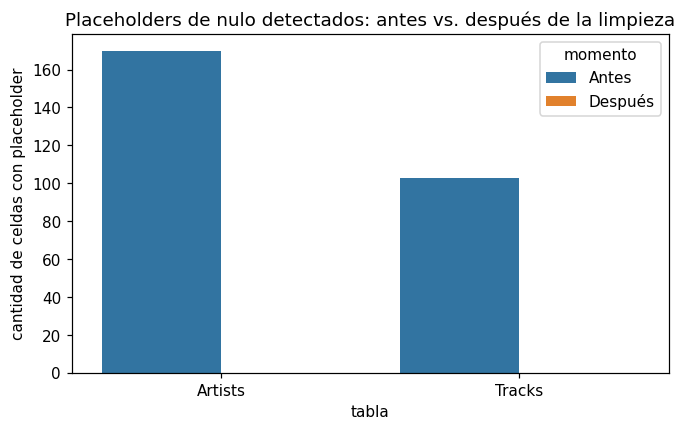

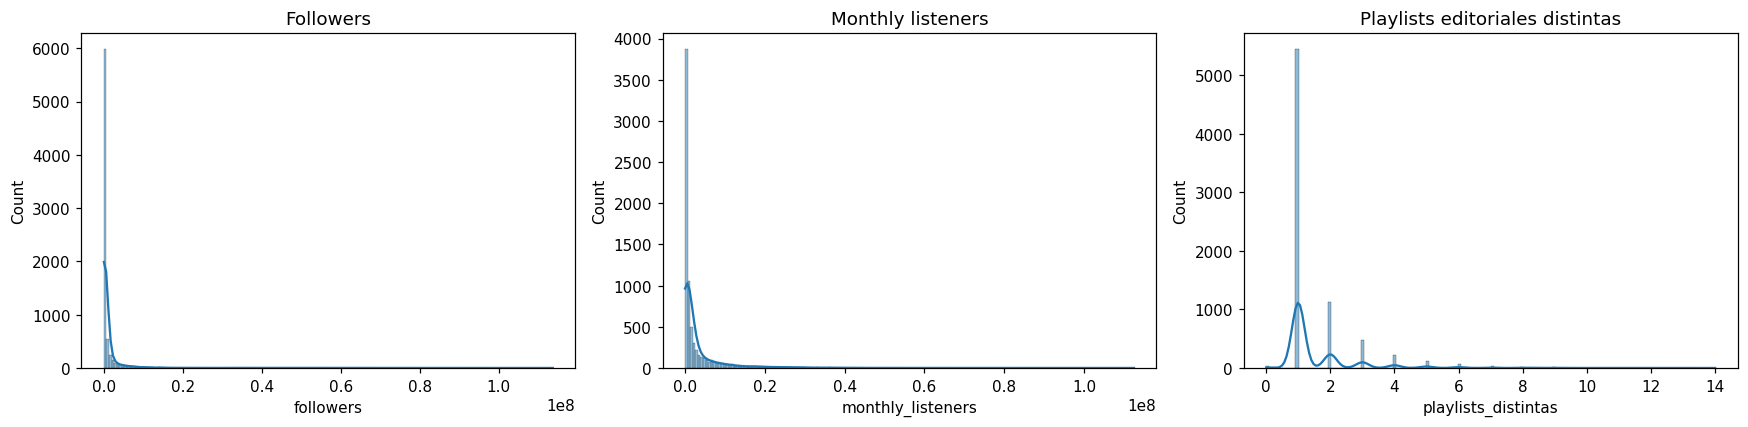

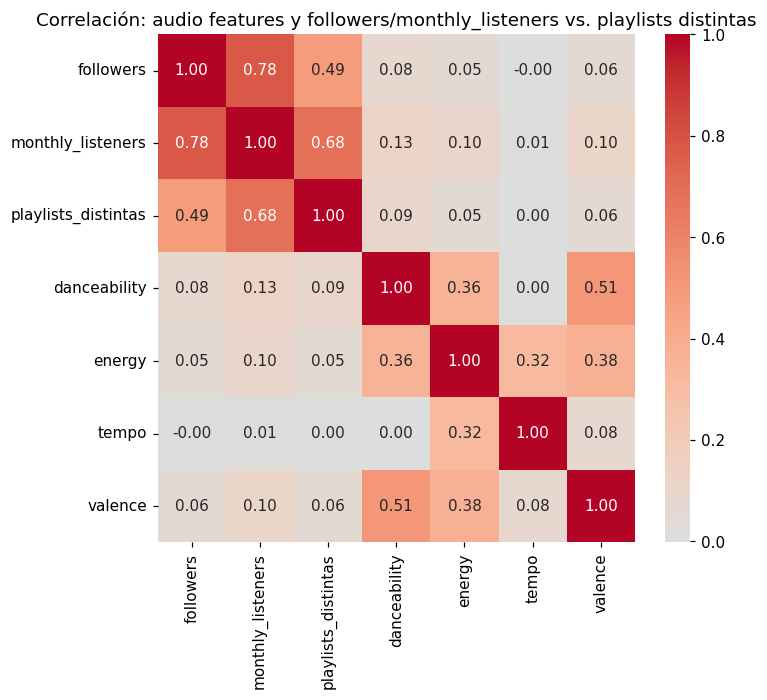

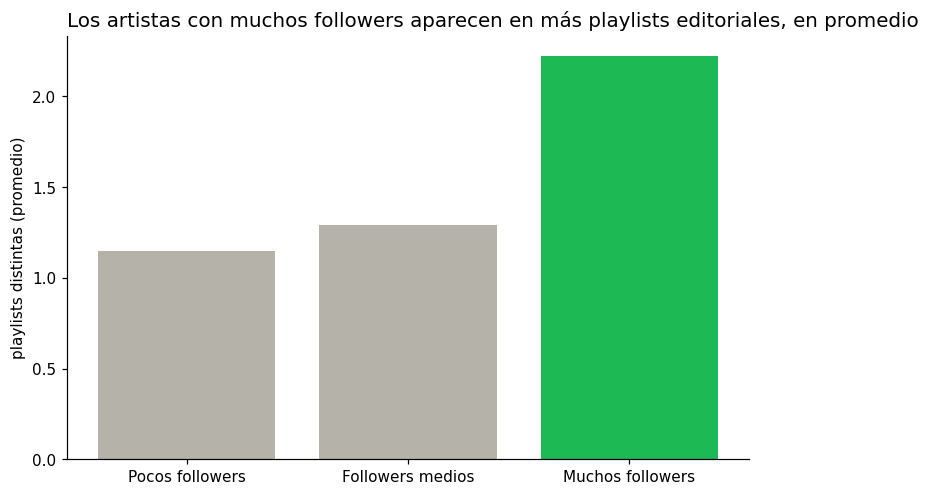

In [19]:
# ETAPA: 5. Análisis Exploratorio (EDA)

# --- Preparación compartida: resumen por artista (para las tasks 02, 03 y 04) ---
playlists_distintas = (
    artist_limpio[artist_limpio["playlists_found"] != "Sin dato"]
    .groupby("ids")["playlists_found"].nunique()
)

resumen_artista = artist_limpio.groupby("ids").agg(
    followers=("followers", "mean"),
    monthly_listeners=("monthly_listeners", "mean"),
)
resumen_artista["playlists_distintas"] = playlists_distintas
resumen_artista["playlists_distintas"] = resumen_artista["playlists_distintas"].fillna(0)


# 01. Resumen de calidad de datos: placeholders antes vs despues (pregunta de apoyo ①)
# Ejemplo: Panorama_Aplicado_Modelos_ML (barplot con hue)
placeholders_artist = ["?", "unknown", "--"]
placeholders_track = ["N/A", "unknown", "?", "--", "not found", ""]

n_placeholders_artist = artist.isin(placeholders_artist).sum().sum()
n_placeholders_track = track.isin(placeholders_track).sum().sum()

resumen_calidad = pd.DataFrame({
    "tabla": ["Artists", "Artists", "Tracks", "Tracks"],
    "momento": ["Antes", "Después", "Antes", "Después"],
    "placeholders": [n_placeholders_artist, 0, n_placeholders_track, 0],
})

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=resumen_calidad, x="tabla", y="placeholders", hue="momento", ax=ax)
ax.set_title("Placeholders de nulo detectados: antes vs. después de la limpieza")
ax.set_ylabel("cantidad de celdas con placeholder")
plt.show()


# 02. Distribución de followers, monthly_listeners y playlists distintas por artista (pregunta de apoyo ②)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(resumen_artista["followers"], kde=True, ax=axes[0])
axes[0].set_title("Followers")
sns.histplot(resumen_artista["monthly_listeners"], kde=True, ax=axes[1])
axes[1].set_title("Monthly listeners")
sns.histplot(resumen_artista["playlists_distintas"], kde=True, ax=axes[2])
axes[2].set_title("Playlists editoriales distintas")
plt.tight_layout()
plt.show()


# 03. Correlación: audio features + followers/monthly_listeners vs. playlists distintas (pregunta de apoyo ③)
columnas_audio_eda = ["danceability", "energy", "tempo", "valence"]
tracks_eda = track_limpio.reset_index(drop=True)

filas_puente = []
for i in range(len(tracks_eda)):
    for artista in tracks_eda.loc[i, "artists"].split(", "):
        fila = {"artists": artista}
        for columna in columnas_audio_eda:
            fila[columna] = tracks_eda.loc[i, columna]
        filas_puente.append(fila)

puente = pd.DataFrame(filas_puente)
audio_por_artista = puente.groupby("artists")[columnas_audio_eda].mean()

tabla_correlacion = resumen_artista.copy()
for columna in columnas_audio_eda:
    tabla_correlacion[columna] = audio_por_artista[columna]
tabla_correlacion = tabla_correlacion.dropna(subset=columnas_audio_eda)
correlaciones = tabla_correlacion.corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(correlaciones, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlación: audio features y followers/monthly_listeners vs. playlists distintas")
plt.show()


# 04. Gráfico honesto de cierre con el hallazgo principal
# Ejemplo: Caja de Herramientas (pd.cut + resaltar una barra con color)
limites = [
    tabla_correlacion["followers"].min() - 1,
    tabla_correlacion["followers"].quantile(1 / 3),
    tabla_correlacion["followers"].quantile(2 / 3),
    tabla_correlacion["followers"].max(),
]
tabla_correlacion["grupo_followers"] = pd.cut(
    tabla_correlacion["followers"], bins=limites,
    labels=["Pocos followers", "Followers medios", "Muchos followers"]
)
resumen_grupos = tabla_correlacion.groupby("grupo_followers", observed=True)["playlists_distintas"].mean()

grupo_top = resumen_grupos.idxmax()
colores = []
for grupo in resumen_grupos.index:
    if grupo == grupo_top:
        colores.append("#1DB954")
    else:
        colores.append("#B4B2A9")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(resumen_grupos.index.astype(str), resumen_grupos.values, color=colores)
ax.set_title(f"Los artistas con {grupo_top.lower()} aparecen en más playlists editoriales, en promedio", loc="left", fontsize=13)
ax.set_ylabel("playlists distintas (promedio)")
for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)
ax.grid(axis="x", visible=False)
plt.show()

print(resumen_grupos.round(2))

## 6. Preparación de la tabla para el modelo

`artist_limpio` tiene una fila por artista **por fecha** (hasta 24 fechas por artista), así que primero se
resume a una fila por artista, promediando followers, monthly_listeners, popularity, num_releases y
num_tracks entre sus fechas.

**Objetivo (y):** `playlists_distintas`, la cantidad de playlists editoriales distintas en las que aparece
el artista (sin contar el placeholder "Sin dato" como si fuera una playlist real).

**Exclusiones** (mismo criterio de la limpieza: se descarta, no se inventa):
- 37 artistas sin ninguna playlist conocida (solo "Sin dato") — no tienen objetivo que predecir.
- 1 artista con `first_release` = 0, un año imposible que la limpieza de Artists no atrapó.
- 260 artistas sin ningún track en `track_limpio` — no tienen audio features.

**Variables predictoras (X):** followers, monthly_listeners, popularity, num_releases, num_tracks,
antigüedad (2024 − primer lanzamiento), los 9 audio features promedio de sus tracks, y el género agrupado
en 13 familias (más de 1,400 géneros distintos de Spotify no caben como variables individuales).

**Tabla final:** 7,286 artistas, 27 variables después de codificar el género con variables 0/1.

In [20]:
# ETAPA: 6. Preparación de la tabla para el modelo de regresión
# 01. Resumir artist_limpio a una fila por artista
# Ejemplo: Panorama_Aplicado_Modelos_ML (agg con nombres)
resumen_modelo = artist_limpio.groupby("ids").agg(
    followers=("followers", "mean"),
    monthly_listeners=("monthly_listeners", "mean"),
    popularity=("popularity", "mean"),
    num_releases=("num_releases", "mean"),
    num_tracks=("num_tracks", "mean"),
    first_release=("first_release", "min"),
)

resumen_modelo["playlists_distintas"] = (
    artist_limpio[artist_limpio["playlists_found"] != "Sin dato"]
    .groupby("ids")["playlists_found"].nunique()
)

print("Artistas sin ninguna playlist conocida (se excluyen):", resumen_modelo["playlists_distintas"].isna().sum())
resumen_modelo = resumen_modelo.dropna(subset=["playlists_distintas"])


# 02. Antigüedad del artista a partir de first_release
print("Artistas con first_release imposible (se excluyen):", (resumen_modelo["first_release"] < 1900).sum())
resumen_modelo = resumen_modelo[resumen_modelo["first_release"] >= 1900]

resumen_modelo["antiguedad"] = 2024 - resumen_modelo["first_release"]
resumen_modelo = resumen_modelo.drop(columns=["first_release"])


# 03. Género: agrupar los géneros de Spotify en familias
resumen_modelo["genero_principal"] = artist_limpio.groupby("ids")["genres"].agg(lambda serie: serie.mode()[0])
resumen_modelo["genero_principal"] = resumen_modelo["genero_principal"].apply(lambda texto: texto.split(",")[0])

familias = [
    ("coreano", ["k-", "korean"]),
    ("latino y caribe", ["latin", "reggaeton", "urbano", "corrido", "mexican", "banda", "sierreno", "cumbia", "bachata", "salsa", "reggae", "kompa"]),
    ("hip hop", ["rap", "hip hop", "trap", "drill", "grime", "phonk"]),
    ("r&b", ["r&b", "soul", "funk"]),
    ("country y folk", ["country", "americana", "bluegrass", "folk", "singer-songwriter", "banjo"]),
    ("instrumental", ["classical", "piano", "sleep", "lo-fi", "ambient", "soundtrack", "orchestra", "focus", "study", "meditation", "new age",
                      "background", "calming", "healing", "binaural", "chill", "baroque"]),
    ("pop", ["pop", "alt z", "boy band"]),
    ("rock", ["rock", "metal", "punk", "grunge", "emo", "hardcore", "indie"]),
    ("electronica", ["house", "edm", "techno", "trance", "step", "electro", "dance", "bass", "hardstyle", "garage", "hyper",
                     "big room", "tronica", "rawstyle", "downtempo", "wave"]),
    ("jazz", ["jazz", "blues"]),
    ("afro", ["afro", "amapiano", "naija"]),
]

resumen_modelo["genero"] = "otro"
resumen_modelo.loc[resumen_modelo["genero_principal"] == "Sin género", "genero"] = "sin genero"
for familia, palabras in familias:
    for palabra in palabras:
        coincide = resumen_modelo["genero_principal"].str.contains(palabra)
        resumen_modelo.loc[coincide & (resumen_modelo["genero"] == "otro"), "genero"] = familia

resumen_modelo = resumen_modelo.drop(columns=["genero_principal"])
print(resumen_modelo["genero"].value_counts())


# 04. Audio features promedio por artista (mismo puente que en el EDA)
columnas_audio_modelo = ["acousticness", "danceability", "energy", "instrumentalness",
                         "liveness", "loudness", "speechiness", "tempo", "valence"]

filas_puente = []
for i in range(len(track_limpio)):
    for artista in track_limpio.loc[i, "artists"].split(", "):
        fila = {"artists": artista}
        for columna in columnas_audio_modelo:
            fila[columna] = track_limpio.loc[i, columna]
        filas_puente.append(fila)

puente_modelo = pd.DataFrame(filas_puente)
audio_modelo = puente_modelo.groupby("artists")[columnas_audio_modelo].mean()

antes = len(resumen_modelo)
tabla_modelo = resumen_modelo.copy()
for columna in columnas_audio_modelo:
    tabla_modelo[columna] = audio_modelo[columna]
tabla_modelo = tabla_modelo.dropna(subset=columnas_audio_modelo)
print("Artistas sin tracks (se excluyen):", antes - len(tabla_modelo))

tabla_modelo = tabla_modelo.reset_index()
print("Tabla final:", tabla_modelo.shape)
print(tabla_modelo.isna().sum().sum(), "nulos")


# 05. Guardar la tabla (descargar desde el icono de carpeta de Colab)
tabla_modelo.to_csv("tabla_modelo.csv", index=False)


# 06. Verificar que la tabla ya sirve para el modelo: X e y
# Ejemplo: Panorama_Aplicado_Modelos_ML (get_dummies + drop_first)
tabla_dummies = pd.get_dummies(tabla_modelo, columns=["genero"], drop_first=True)
X = tabla_dummies.drop(columns=["ids", "playlists_distintas"])
y = tabla_dummies["playlists_distintas"]
print("X:", X.shape, "| y:", y.shape)
print("Variables:", X.columns.tolist())
print(y.describe().round(2))

Artistas sin ninguna playlist conocida (se excluyen): 37
Artistas con first_release imposible (se excluyen): 1
genero
rock               1006
electronica        1005
pop                 956
instrumental        823
hip hop             810
country y folk      752
otro                724
coreano             431
r&b                 398
sin genero          231
latino y caribe     202
jazz                115
afro                 93
Name: count, dtype: int64
Artistas sin tracks (se excluyen): 260
Tabla final: (7286, 18)
0 nulos
X: (7286, 27) | y: (7286,)
Variables: ['followers', 'monthly_listeners', 'popularity', 'num_releases', 'num_tracks', 'antiguedad', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'genero_coreano', 'genero_country y folk', 'genero_electronica', 'genero_hip hop', 'genero_instrumental', 'genero_jazz', 'genero_latino y caribe', 'genero_otro', 'genero_pop', 'genero_r&b', 'genero_rock', 'genero_sin gene

## 7. Modelo de regresión

Responde la pregunta principal del proyecto: ¿qué tan bien puede un modelo de regresión, entrenado con el
perfil del artista y los audio features de sus tracks, estimar en cuántas playlists editoriales distintas
aparecerá un artista que no vio durante el entrenamiento?

El 20% de los artistas se reserva como examen (`test`): el modelo nunca los ve al entrenar, así que sirven
para medir qué tan bien generaliza a artistas nuevos.

In [21]:
# Ejemplo: Panorama_Aplicado_Modelos_ML y Quiz Corte 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)

SEED = 42
np.random.seed(SEED)

### 7.1 Regresión lineal múltiple

`monthly_listeners` es, por mucho, la variable más importante (coeficiente +0.827 con las variables
escaladas), seguida de `popularity` (+0.191). Los audio features (qué tan bailable, energética o positiva
es la música) pesan menos de 0.05 cada uno — no importan casi nada para predecir la presencia en playlists.

**`followers` sale con coeficiente negativo** (-0.10) a pesar de correlacionar positivamente con el
objetivo (+0.49) por sí sola. Es multicolinealidad: `followers` y `monthly_listeners` están correlacionadas
entre sí (0.78), y una vez que `monthly_listeners` ya está en el modelo, el aporte de `followers` cambia de
signo. Este mismo fenómeno se explica en el material de clase (Panorama_Aplicado_Modelos_ML, sección 2).

**Desempeño en el examen (test):** RMSE 0.886 playlists, R² 0.433 — el modelo explica el 43% de la
diferencia entre artistas. Como referencia, adivinar siempre el promedio (1.56 playlists) tendría un RMSE
de 1.177: el modelo sí aprende una relación real, aunque moderada.

In [22]:
# MODELO 01. Regresión lineal múltiple
# Ejemplo: Panorama_Aplicado_Modelos_ML (regresión lineal múltiple + StandardScaler)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

modelo_lineal_multiple = LinearRegression()
modelo_lineal_multiple.fit(X_train_sc, y_train)
y_pred = modelo_lineal_multiple.predict(X_test_sc)

coefs = pd.Series(modelo_lineal_multiple.coef_, index=X.columns)
print("Coeficientes (variables escaladas):")
print(coefs.sort_values(ascending=False).round(3))

print(f"\nIntercepto: {modelo_lineal_multiple.intercept_:.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f} playlists")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.3f} playlists")
print(f"R2: {r2_score(y_test, y_pred):.3f}")
print(f"Desviación estándar de y_test: {y_test.std():.3f}")

Coeficientes (variables escaladas):
monthly_listeners         0.827
popularity                0.191
genero_coreano            0.062
genero_country y folk     0.059
genero_r&b                0.023
valence                   0.022
genero_rock               0.011
genero_jazz               0.010
genero_instrumental       0.006
num_releases              0.005
genero_pop                0.004
instrumentalness          0.004
liveness                  0.002
speechiness              -0.003
tempo                    -0.004
loudness                 -0.010
genero_electronica       -0.011
danceability             -0.014
genero_otro              -0.015
acousticness             -0.015
genero_hip hop           -0.019
genero_sin genero        -0.024
energy                   -0.041
num_tracks               -0.044
antiguedad               -0.080
followers                -0.104
genero_latino y caribe   -0.106
dtype: float64

Intercepto: 1.569
RMSE: 0.886 playlists
MAE: 0.562 playlists
R2: 0.433
Desviación es

### 7.2 Regularización: Ridge y Lasso

Ridge (alpha=1.0) no cambia el resultado frente a la regresión sin regularizar: con casi 5,800 artistas de
entrenamiento, ese nivel de penalización es demasiado suave.

**Lasso (alpha=0.05) sí es el hallazgo relevante:** con solo 7 de las 27 variables, pierde menos de un
punto de R² (0.424 frente a 0.433). Las 20 variables restantes — followers, los 9 audio features y la
mayoría de los géneros — aportaban tan poco que Lasso las llevó exactamente a cero.

**Respuesta a la pregunta de apoyo ④ (selección de variables):** para predecir la presencia en playlists
alcanza con la audiencia del artista (`monthly_listeners`, `popularity`) y, en menor medida, el género y la
antigüedad. El sonido de las canciones no aporta.

**Por eso elegimos Lasso (alpha=0.05) como modelo final:** iguala el desempeño de OLS y Ridge en
validación cruzada usando solo 7 de las 27 variables, y es el único de los tres que responde por sí mismo
cuáles variables importan.

In [23]:
# MODELO 02. Regularización: Ridge y Lasso
# Ejemplo: Panorama_Aplicado_Modelos_ML (comparación OLS vs Ridge vs Lasso)
modelos_reg = {
    "OLS sin regularizar": LinearRegression(),
    "Ridge (alpha=1.0)": Ridge(alpha=1.0, random_state=SEED),
    "Lasso (alpha=0.05)": Lasso(alpha=0.05, random_state=SEED),
}

resultados = []
coefs_por_modelo = {}

for nombre, modelo in modelos_reg.items():
    modelo.fit(X_train_sc, y_train)
    pred = modelo.predict(X_test_sc)
    resultados.append({
        "Modelo": nombre,
        "RMSE test": np.sqrt(mean_squared_error(y_test, pred)),
        "R2 test": r2_score(y_test, pred),
        "Coeficientes != 0": int(np.sum(np.abs(modelo.coef_) > 1e-6)),
        "Suma |coeficientes|": np.abs(modelo.coef_).sum(),
    })
    coefs_por_modelo[nombre] = modelo.coef_

tabla_resultados = pd.DataFrame(resultados).round(3)
print(tabla_resultados.to_string(index=False))

tabla_coefs = pd.DataFrame(coefs_por_modelo, index=X.columns)
print("\nCoeficientes por modelo:")
print(tabla_coefs.sort_values("Lasso (alpha=0.05)", ascending=False).round(4).to_string())

eliminadas = tabla_coefs[np.abs(tabla_coefs["Lasso (alpha=0.05)"]) <= 1e-6].index.tolist()
print(f"\nVariables que Lasso llevó a cero ({len(eliminadas)} de {X.shape[1]}):")
print(eliminadas)

# Modelo final: Lasso iguala a OLS/Ridge en validación cruzada usando solo 7 de 27 variables
modelo_final = modelos_reg["Lasso (alpha=0.05)"]
y_pred = modelo_final.predict(X_test_sc)

             Modelo  RMSE test  R2 test  Coeficientes != 0  Suma |coeficientes|
OLS sin regularizar      0.886    0.433                 27                1.716
  Ridge (alpha=1.0)      0.886    0.433                 27                1.715
 Lasso (alpha=0.05)      0.893    0.424                  7                0.934

Coeficientes por modelo:
                        OLS sin regularizar  Ridge (alpha=1.0)  Lasso (alpha=0.05)
monthly_listeners                    0.8274             0.8269              0.6984
popularity                           0.1910             0.1911              0.1508
genero_country y folk                0.0590             0.0589              0.0067
genero_coreano                       0.0623             0.0623              0.0019
acousticness                        -0.0153            -0.0152              0.0000
num_releases                         0.0050             0.0050              0.0000
danceability                        -0.0142            -0.0142           

### 7.3 Validación cruzada

Un solo examen (`train_test_split`) depende de qué artistas cayeron por azar en ese 20%. Con validación
cruzada de 5 particiones (`KFold`), el modelo se entrena y se examina 5 veces, cada vez con un grupo
distinto de artistas como examen.

**R² promedio: 0.498 (± 0.043)** para la regresión sin regularizar — más alto y más confiable que el 0.433
de un solo examen, que resultó ser el más exigente de los 5. La variación entre particiones es baja (±0.043),
así que el resultado es estable y no depende de la suerte de una sola división de los datos.

OLS sin regularizar   : R2 por fold = [0.433 0.489 0.498 0.499 0.569]
                        R2 promedio = 0.498  (+/- 0.043)
Ridge (alpha=1.0)     : R2 por fold = [0.433 0.489 0.498 0.499 0.569]
                        R2 promedio = 0.498  (+/- 0.043)
Lasso (alpha=0.05)    : R2 por fold = [0.424 0.471 0.472 0.487 0.56 ]
                        R2 promedio = 0.483  (+/- 0.044)


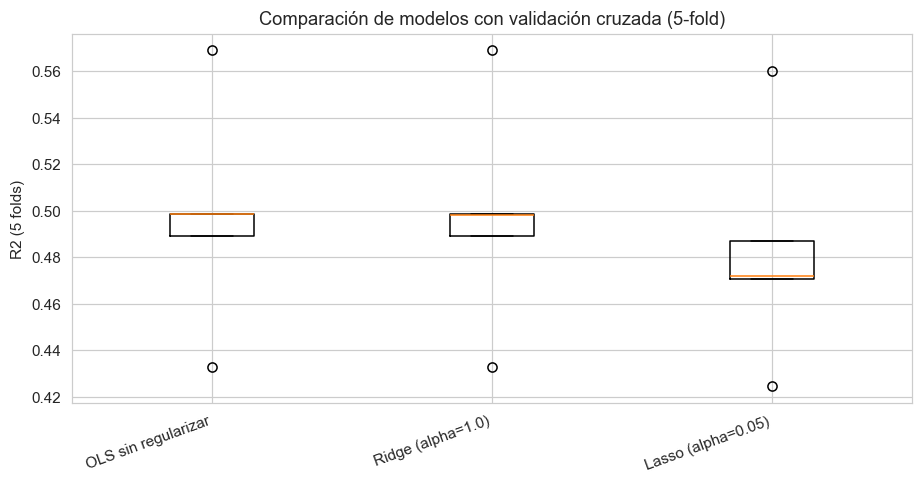

In [24]:
# MODELO 03. Validación cruzada
# Ejemplo: Panorama_Aplicado_Modelos_ML (cross_val_score + make_pipeline).
# Ese notebook usa StratifiedKFold para clasificación; KFold es la versión que menciona para regresión.
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

modelos_cv = {
    "OLS sin regularizar": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge (alpha=1.0)": make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=SEED)),
    "Lasso (alpha=0.05)": make_pipeline(StandardScaler(), Lasso(alpha=0.05, random_state=SEED)),
}

resultados_cv = {}
for nombre, modelo in modelos_cv.items():
    scores = cross_val_score(modelo, X, y, cv=cv)
    resultados_cv[nombre] = scores
    print(f"{nombre:22s}: R2 por fold = {scores.round(3)}")
    print(f"{'':22s}  R2 promedio = {scores.mean():.3f}  (+/- {scores.std():.3f})")

plt.figure(figsize=(8.5, 4.5))
nombres = list(resultados_cv.keys())
plt.boxplot([resultados_cv[n] for n in nombres])
plt.xticks(range(1, len(nombres) + 1), nombres, rotation=20, ha="right")
plt.ylabel("R2 (5 folds)")
plt.title("Comparación de modelos con validación cruzada (5-fold)")
plt.tight_layout()
plt.show()

### 7.4 Evaluación final: real vs. predicho

**Respuesta a la pregunta de apoyo ⑤ (validación del modelo):** sobre los artistas de test, el modelo
final (Lasso) tiene un error promedio (MAE) de 0.561 playlists y un RMSE de 0.893 playlists, con R² de
0.424 — prácticamente igual al de la regresión sin regularizar (0.433), pero con solo 7 variables en vez
de 27. El gráfico de dispersión confirma lo mismo visualmente: los puntos se agrupan cerca de la diagonal
para valores bajos (la mayoría de artistas, con 1-3 playlists), pero el modelo tiende a subestimar a los
pocos artistas que aparecen en muchas playlists — es más fácil predecir el caso típico que el caso
extremo.

 RMSE   MAE    R2
0.893 0.561 0.424


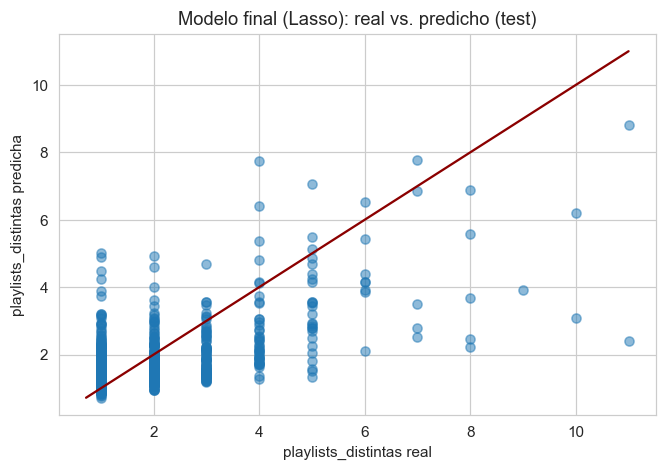

In [25]:
# MODELO 04. Evaluación final: real vs. predicho y tabla de métricas (pregunta de apoyo ⑤)
# Ejemplo: Quiz Corte 2 (Script_Inicio_Python / Notebook2026)
tabla_metricas = pd.DataFrame([{
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
    "MAE": mean_absolute_error(y_test, y_pred),
    "R2": r2_score(y_test, y_pred),
}]).round(3)
print(tabla_metricas.to_string(index=False))

fig, ax = plt.subplots()
ax.scatter(y_test, y_pred, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, color="darkred")
ax.set_xlabel("playlists_distintas real")
ax.set_ylabel("playlists_distintas predicha")
ax.set_title("Modelo final (Lasso): real vs. predicho (test)")
plt.show()

## 8. Conclusiones y recomendaciones

1. **El tamaño de audiencia ya construido predice la presencia en playlists editoriales mejor que el
   sonido de la música.** `monthly_listeners` es la variable más importante en todos los modelos probados;
   ningún audio feature (danceability, energy, tempo, valence, etc.) tiene un peso relevante.
2. **El modelo final (Lasso) tiene una precisión moderada, no alta.** Explica en promedio el 48% de la
   diferencia entre artistas (R² = 0.483 con validación cruzada), con un error típico de aproximadamente
   media playlist (MAE = 0.56). El otro ~50% depende de factores que no están en los datos, como decisiones
   editoriales o relaciones con las disqueras.
3. **Correlación no es causalidad.** El hallazgo dice que `monthly_listeners` es el mejor indicador
   disponible de la presencia en playlists, no que aumentar los oyentes garantice más playlists — la
   relación también puede ir en la otra dirección (estar en más playlists atrae más oyentes).
4. **Recomendación práctica:** para alguien que decide en qué artistas invertir en promoción musical, el
   historial de audiencia (oyentes mensuales, popularidad) es una señal mucho más confiable que el estilo
   musical de las canciones a la hora de estimar la presencia futura en playlists editoriales.
5. **Limitaciones:** el modelo se entrenó con datos de un solo periodo (abril-mayo de 2024) y solo con
   artistas que ya tenían presencia en playlists editoriales en Estados Unidos; no está validado para
   artistas completamente nuevos sin ningún historial, ni para otras plataformas o mercados.